# Triple Pendulum

Rebuilt from `legacy/Triple Pendulum.ipynb` through `lagrangian.py`. Same
setup: `m1=2, m2=1, m3=1, L1=2, L2=1, L3=1`, initial condition
`(theta1,theta2,theta3)=(-pi/2, 1, 2)` at rest.

Same two-part validation as `Double_Pendulum.ipynb`: energy conservation
over a long chaotic run, and small-amplitude oscillation frequencies
against `lagrangian.linearize()`'s normal modes.

Building this notebook is also what caught a real performance bug in
`lagrangian.py`: the original `euler_lagrange` used a generic nonlinear
`sp.solve` for the accelerations, which did not finish in several minutes
for 3 coupled coordinates (the Double Pendulum's 2-coordinate case was
fine). Since the Euler-Lagrange equations are always linear in the
accelerations, `euler_lagrange` now extracts the mass matrix via
`sp.linear_eq_to_matrix` and solves by matrix inversion instead --
exact, and this system now solves in ~0.2s. (A further `sp.simplify()` on
the result was also tried and made things *slower*, not faster, for the
same reason -- removed.)

In [1]:
import os
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import lagrangian as lg

os.makedirs('media', exist_ok=True)

In [2]:
t, g, m1, m2, m3, L1, L2, L3 = sp.symbols('t g m1 m2 m3 L1 L2 L3')
the1 = sp.Function('the1')(t)
the2 = sp.Function('the2')(t)
the3 = sp.Function('the3')(t)

x1 = L1 * sp.sin(the1); y1 = -L1 * sp.cos(the1)
x2 = x1 + L2 * sp.sin(the2); y2 = y1 - L2 * sp.cos(the2)
x3 = x2 + L3 * sp.sin(the3); y3 = y2 - L3 * sp.cos(the3)

T = (0.5*m1*(sp.diff(x1,t)**2+sp.diff(y1,t)**2)
     + 0.5*m2*(sp.diff(x2,t)**2+sp.diff(y2,t)**2)
     + 0.5*m3*(sp.diff(x3,t)**2+sp.diff(y3,t)**2))
U = m1*g*y1 + m2*g*y2 + m3*g*y3
L = T - U
coords = [the1, the2, the3]

import time
t0 = time.time()
sols, coords_d, coords_dd = lg.euler_lagrange(L, coords, t)
print(f'euler_lagrange: {time.time()-t0:.2f}s')

dSdt = lg.build_ode_system(sols, coords, coords_d, t, (g, m1, m2, m3, L1, L2, L3))
energy = lg.energy_fn(T, U, coords, coords_d, (g, m1, m2, m3, L1, L2, L3))

euler_lagrange: 0.23s


## Chaotic run: energy conservation

Energy: mean=-6.518366, relative drift=1.33e-05


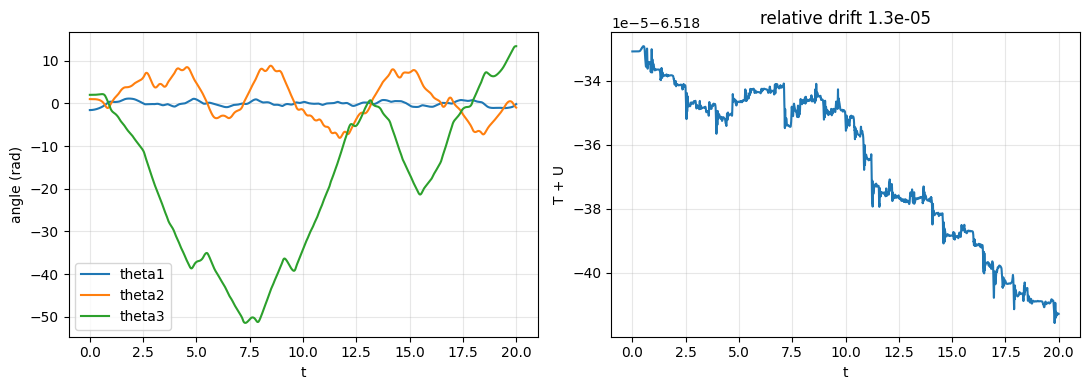

PASS: energy conserved over the full chaotic run.


In [3]:
params = (9.81, 2.0, 1.0, 1.0, 2.0, 1.0, 1.0)
N = 4000
t_arr = np.linspace(0, 20, N)
sol = lg.integrate(dSdt, [-np.pi/2, 0, 1, 0, 2, 0], t_arr, params)
the1_t, w1_t, the2_t, w2_t, the3_t, w3_t = sol.T

E = np.array([energy(the1_t[i], the2_t[i], the3_t[i], w1_t[i], w2_t[i], w3_t[i], *params) for i in range(N)])
drift = E.max() - E.min()
print(f'Energy: mean={E.mean():.6f}, relative drift={drift/abs(E.mean()):.2e}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t_arr, the1_t, label='theta1')
axes[0].plot(t_arr, the2_t, label='theta2')
axes[0].plot(t_arr, the3_t, label='theta3')
axes[0].set_xlabel('t'); axes[0].set_ylabel('angle (rad)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(t_arr, E)
axes[1].set_xlabel('t'); axes[1].set_ylabel('T + U')
axes[1].set_title(f'relative drift {drift/abs(E.mean()):.1e}'); axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/triple_pendulum_energy.png', dpi=150, bbox_inches='tight')
plt.show()

assert drift / abs(E.mean()) < 1e-3, f'energy drift too large: {drift/abs(E.mean()):.2e}'
print('PASS: energy conserved over the full chaotic run.')

## Small-amplitude limit vs. `linearize()`

In [4]:
M, K, _ = lg.linearize(L, coords, t, equilibrium={the1: 0, the2: 0, the3: 0})
pvals = {g: 9.81, m1: 2.0, m2: 1.0, m3: 1.0, L1: 2.0, L2: 1.0, L3: 1.0}
freqs = lg.normal_mode_frequencies(M, K, pvals)
print('linearize() normal-mode frequencies:', freqs)

t_small = np.linspace(0, 150, 30000)
sol_small = lg.integrate(dSdt, [0.02, 0, -0.015, 0, 0.01, 0], t_small, params)
dt = t_small[1] - t_small[0]
spec = np.abs(np.fft.rfft(sol_small[:, 0] - sol_small[:, 0].mean()))
fr = 2 * np.pi * np.fft.rfftfreq(len(t_small), d=dt)

from scipy.signal import find_peaks
peaks, _ = find_peaks(spec)
top = sorted(peaks[np.argsort(spec[peaks])[::-1][:3]], key=lambda i: fr[i])
fft_freqs = np.array([fr[i] for i in top])
print('FFT peak frequencies:', fft_freqs)

err = np.max(np.abs(np.sort(fft_freqs) - np.sort(freqs)) / freqs)
print(f'max relative error: {err:.3f}')
assert err < 0.05, f'small-amplitude FFT frequencies do not match linearize(): {err:.3f}'
print('PASS: all 3 small-amplitude normal-mode frequencies match linearize().')

linearize() normal-mode frequencies: [1.7852076  3.78557224 6.42981156]


FFT peak frequencies: [1.80111975 3.76978552 6.40863539]
max relative error: 0.009
PASS: all 3 small-amplitude normal-mode frequencies match linearize().


## Animation (chaotic run)

In [5]:
x1_t = params[4]*np.sin(the1_t); y1_t = -params[4]*np.cos(the1_t)
x2_t = x1_t + params[5]*np.sin(the2_t); y2_t = y1_t - params[5]*np.cos(the2_t)
x3_t = x2_t + params[6]*np.sin(the3_t); y3_t = y2_t - params[6]*np.cos(the3_t)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_facecolor('k')
ax.set(xlim=(-4.5, 4.5), ylim=(-4.5, 4.5))
ax.set_xticks([]); ax.set_yticks([])
trail, = ax.plot([], [], '-', color='orange', alpha=0.4, linewidth=0.8)
line, = ax.plot([], [], 'o-', color='white', markersize=8)
trail_x, trail_y = [], []

def animate(i):
    line.set_data([0, x1_t[i], x2_t[i], x3_t[i]], [0, y1_t[i], y2_t[i], y3_t[i]])
    trail_x.append(x3_t[i]); trail_y.append(y3_t[i])
    trail.set_data(trail_x[-300:], trail_y[-300:])
    return line, trail

ani = animation.FuncAnimation(fig, animate, frames=N, interval=20, blit=True)
ani.save('media/triple_pendulum.mp4', writer='ffmpeg', fps=50, dpi=130)
plt.close(fig)
print('saved media/triple_pendulum.mp4')

saved media/triple_pendulum.mp4
